# Executive summary
In this analysis of a 12,330-session Online Retail Dataset, key insights were uncovered through exploratory data analysis (EDA) and predictive modeling. The EDA highlighted the significant impact of Product-Related pages and engagement metrics on purchases, with distinct trends observed in user behavior across seasons and technologies. This led to strategic recommendations for enhancing user experience and conversion rates.

Subsequently, a RandomForestClassifier, refined with SMOTE and hyperparameter tuning, effectively addressed class imbalance, improving the model's capability to identify potential Buyers with an accuracy of 88.1%. This combined approach of EDA and advanced modeling techniques demonstrates the potential of data-driven strategies to optimize online retail platforms, balancing user engagement insights with predictive accuracy.

# Table of content
* [Introduction](#dataset_explain)
    * [Dataset Description](#dataset_explain)
    * [Business Objective](#business_question)
* [Exploratory Data Analysis (EDA)](#eda)
    * [Initial Observations](#quick_overview)
    * [Data Cleaning & Manipulation](#cleaning)
    * [In-depth Data Analysis](#analyze)
        * [Page interaction analysis](#page_analysis)
        * [Engagement metrics analysis](#rate_analysis)
        * [Trends Analysis over Time](#time_series_analysis)
        * [Categorical analysis](#category_analysis)
    * [EDA Conclusion](#conclusion)
        * [Key Business Insight](#insight)
        * [Recommendations](#recommend)
* [Predictive modeling](#predict)
    * [Key Features](#keyfeature)
    * [SMOTE Application](#smote)
    * [Cross Validation](#crossvalidation)
    * [Hyper Parameter Tunning](#hyper)
    * [Conclusion of Predictive Modeling](#modelconslusion)

# Introduction
## Dataset Descriptions <a class="anchor"  id="dataset_explain"></a>
This dataset contains feature vectors for 12,330 sessions, each representing a different user over a 1-year period. The data is curated to avoid bias towards specific campaigns, special days, user profiles, or periods.


**Features**
* **Administrative** :The number of pages of this type (administrative) visited by the user in that session.
* **Administrative_Duration** : The total amount of time (in seconds) spent by the user on administrative pages during the session.
* **Informational**: The number of informational pages visited by the user in that session.
* **Informational_Duration** : The total time spent by the user on informational pages.
* **ProductRelated** : The number of product-related pages visited by the user.
* **ProductRelated_Duration** : The total time spent by the user on product-related pages.
* **BounceRates** : The average bounce rate of the pages visited by the user. The bounce rate is the percentage of visitors who navigate away from the site after viewing only one page.
* **ExitRates** : The average exit rate of the pages visited by the user. The exit rate is a metric that shows the percentage of exits from a page.
* **PageValues** : The average value of the pages visited by the user. This metric is often used as an indicator of how valuable a page is in terms of generating revenue.
* **SpecialDay** : This indicates the closeness of the site visiting time to a specific special day (e.g., Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with a transaction.
* **Month** : The month of the year in which the session occurred.
OperatingSystems: The operating system used by the user.
* **Browser** : The browser used by the user.
* **Region** : The region from which the user is accessing the website.
* **TrafficType** : The type of traffic (e.g., direct, paid search, organic search, referral).
* **VisitorType** : A categorization of users (e.g., Returning Visitor, New Visitor).
* **Weekend** : A boolean indicating whether the session occurred on a weekend.

**Target Variable** <a class="anchor"  id="target_explain"></a>
* **Revenue** :
A binary variable indicating whether the session ended in a transaction (purchase).

## **Business Objective¶** <a class="anchor"  id="business_question"></a>
In this section, we delve into the online shopping behaviors of users. Our analysis aims to uncover significant relationships and patterns. The business objectives for this dataset include:
1. Investigating the relationship between user interactions (**views, duration**) on **Administrative/Informational/ProductRelated** pages and **Revenue** generation.
2. Exploring whether **Bounce Rate** and **Exit Rate** are indicative of **Revenue** outcomes.
3. Determining if **Revenue** generation is influenced by specific time periods, such as **special days, months, or weekends**.
4. Identifying the most prevalent **Browser/Operating System** combinations used in online shopping.
5. Pinpointing which **Region** contributes the highest visitor traffic to the website.
6. Assessing which **Traffic Type** is predominantly utilized by users.
7. Given the dataset includes over **10 variables**, determining which features are most influential in driving purchase decisions.

# Explainatory Data Analysis (EDA) <a class="anchor"  id="eda"></a>

This section encompasses the entire data analytics process, aiming to address the questions posed by marketing teams or stakeholders. It methodically covers data exploration, cleaning, manipulation, and in-depth analysis. The primary tools utilized for this analysis are **matplotlib** and **seaborn**.

## Initial Observations <a class="anchor"  id="quick_overview"></a>

**Setting Up the Environment and Importing Libraries**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-shoppers-intention/online_shoppers_intention.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Loading the Data**

In [3]:
df = pd.read_csv('/kaggle/input/online-shoppers-intention/online_shoppers_intention.csv')

**Exploring Data Characteristics**

The `df.describe(include='all')` function is utilized to gain an overview of the dataset's characteristics. This includes summarizing mean values, standard deviations, and ranges for numerical features, as well as displaying top categories and their frequencies for categorical features.

In [4]:
df.describe(include='all')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


**Previewing the Dataset**

The first few rows of the dataset are displayed using df.head(), providing an initial glimpse into the data's structure and the types of values it contains.

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Data Cleaning & Manipulation <a class="anchor"  id="cleaning"></a>

Although the dataset is largely clean, as provided by the data source, there are some inconsistencies that need addressing. The following exploration will help identify and rectify these inconsistencies.

In [6]:
df.groupby('Month').agg('count')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
Month,,,,,,,,,,,,,,,,,
Aug,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433
Dec,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727,1727
Feb,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184
Jul,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432
June,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288
Mar,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907
May,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364
Nov,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998
Oct,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549


Upon examining the **'Month'** column, it was observed that most months are abbreviated (e.g., JUL, AUG, DEC), but one entry uses 'June' instead of 'Jun'. To maintain consistency, this will be corrected. Additionally, there is an absence of data for January and April; these months will be excluded from the analysis for consistency.

In [7]:
df.loc[df['Month'] == 'June', 'Month'] = 'Jun'

In [8]:
# Define the order of the months
month_order = ['Feb', 'Mar', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert the 'Month' column to a categorical type with the defined order
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

In [9]:
df.groupby('Month').agg('count')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
Month,,,,,,,,,,,,,,,,,
Feb,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184,184
Mar,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907,1907
May,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364,3364
Jun,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288,288
Jul,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432,432
Aug,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433,433
Sep,448,448,448,448,448,448,448,448,448,448,448,448,448,448,448,448,448
Oct,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549,549
Nov,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998,2998


**Checking for Null Data**

In [10]:
df.notnull().all()

Administrative             True
Administrative_Duration    True
Informational              True
Informational_Duration     True
ProductRelated             True
ProductRelated_Duration    True
BounceRates                True
ExitRates                  True
PageValues                 True
SpecialDay                 True
Month                      True
OperatingSystems           True
Browser                    True
Region                     True
TrafficType                True
VisitorType                True
Weekend                    True
Revenue                    True
dtype: bool

## **In-depth Analysis** <a class="anchor"  id="analyze"></a>
This section analyzes the data to answer the business questions identified earlier. The analysis is illustrated through both graphical and tabular formats and includes four main areas: Page Interaction Analysis, Rate Analysis, Time-Series Analysis, and Categorical Analysis.

## Page interaction analysis <a class="anchor"  id="page_analysis"></a>
This analysis focuses on understanding online shopping behaviors through page interactions, specifically the frequency and duration of visits to Administrative, Informational, and Product-Related pages. The aim is to identify which page type most influences purchasing decisions. The analysis also considers the VisitorType variable to understand different visitor behaviors.

**Feature to be consider**
* Revenue
* Administrative
* Administrative_Duration
* Informational
* Informational_Duration
* ProductRelated
* ProductRelated_Duration
* VisitorType

The analysis starts by calculating the average number of pages viewed in each session, categorized by whether the session resulted in revenue.

In [11]:
# Aggregate the data using mean
page_cnt_df = df.groupby('Revenue')[['Administrative', 'Informational', 'ProductRelated']].mean().reset_index()

# Chage values of Revenue column to be more readable data
page_cnt_df.loc[page_cnt_df['Revenue'] == True, 'Revenue'] = 'Buyers'
page_cnt_df.loc[page_cnt_df['Revenue'] == False, 'Revenue'] = 'Non-Buyers'
page_cnt_df

,Revenue,Administrative,Informational,ProductRelated
0,Non-Buyers,2.117732,0.451833,28.714642
1,Buyers,3.393606,0.786164,48.210168


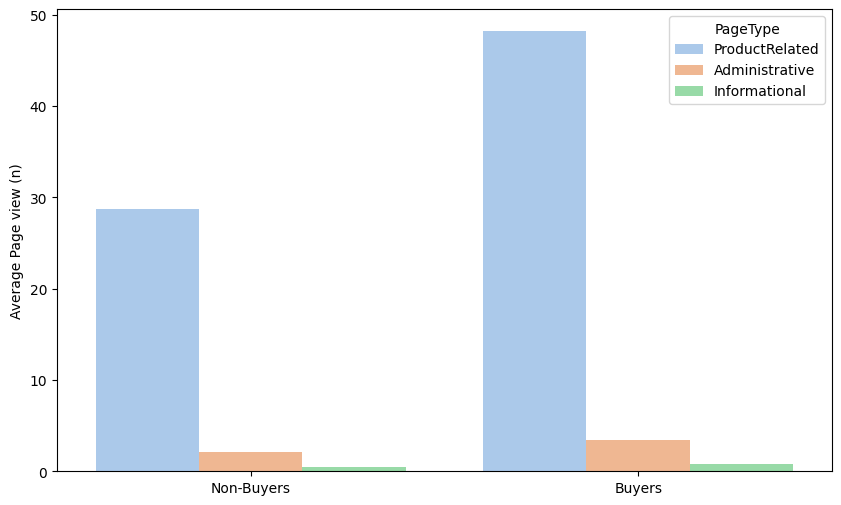

In [12]:
# Create melted df for make it easy to plot 
melted_df = page_cnt_df.melt(id_vars='Revenue', value_vars=[ 'ProductRelated', 'Administrative', 'Informational'],
                            var_name='PageType', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Revenue', y='Value', hue='PageType', palette='pastel')
plt.xlabel('')
plt.ylabel('Average Page view (n)')
plt.show()

The bar plot indicates that sessions resulting in purchases (Buyers) have higher average views on Product-Related pages compared to sessions without purchases (Non-Buyers). This suggests that 
> Engagement with **Product-Related pages** is a significant factor in leading to purchases.

Next, the analysis examines the duration of time visitors spend on each page type to see if there is a similar trend to the page view data. The duration units are converted for better comprehension.

In [13]:
# Build df for duration count
page_dur_cnt = df.groupby('Revenue')[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']].mean()

# change duration in sec to minitues
page_dur_cnt = page_dur_cnt.apply(lambda x : x/60).reset_index()

# Chage values of Revenue column to be more readable data
page_dur_cnt.loc[page_dur_cnt['Revenue'] == True, 'Revenue'] = 'Buyers'
page_dur_cnt.loc[page_dur_cnt['Revenue'] == False, 'Revenue'] = 'Non-Buyers'

page_dur_cnt

,Revenue,Administrative_Duration,Informational_Duration,ProductRelated_Duration
0,Non-Buyers,1.229002,0.503937,17.83313
1,Buyers,1.991387,0.960190,31.27016


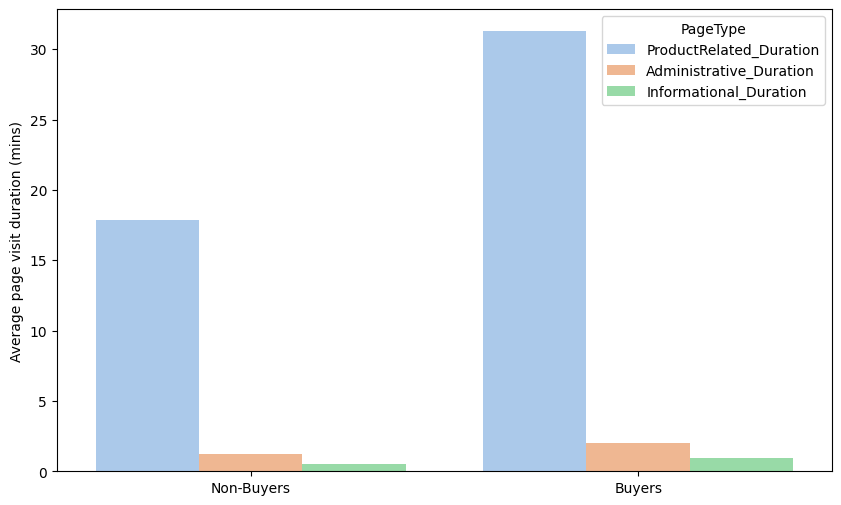

In [14]:
#Melt the dataframe for easy to plot
melt_page_dur_cnt = page_dur_cnt.melt(id_vars='Revenue', 
                                      value_vars=[ 'ProductRelated_Duration', 'Administrative_Duration', 'Informational_Duration'],
                                      var_name='PageType', value_name='TotalDuration')

plt.figure(figsize=(10, 6))
sns.barplot(data=melt_page_dur_cnt, 
            x='Revenue', 
            y='TotalDuration', 
            hue='PageType', 
            palette='pastel')
plt.xlabel('')
plt.ylabel('Average page visit duration (mins)')
plt.show()


Based on the plot of page duration, the average duration time that visitors spend on Product related page are higher than other 2 pages. This behavior also has the same trends with the count of page view. It can be conclude that
> **Buyers** are most likely to stay on Product related page more than **Non-Buyers**

The plot of page visit durations shows that Buyers tend to spend more time on Product-Related pages compared to Non-Buyers, reinforcing the trend observed in page view counts. 
> This underscores the importance of **Product-Related pages** in influencing purchasing decisions.

**Analysis of Visitor Type Numbers**

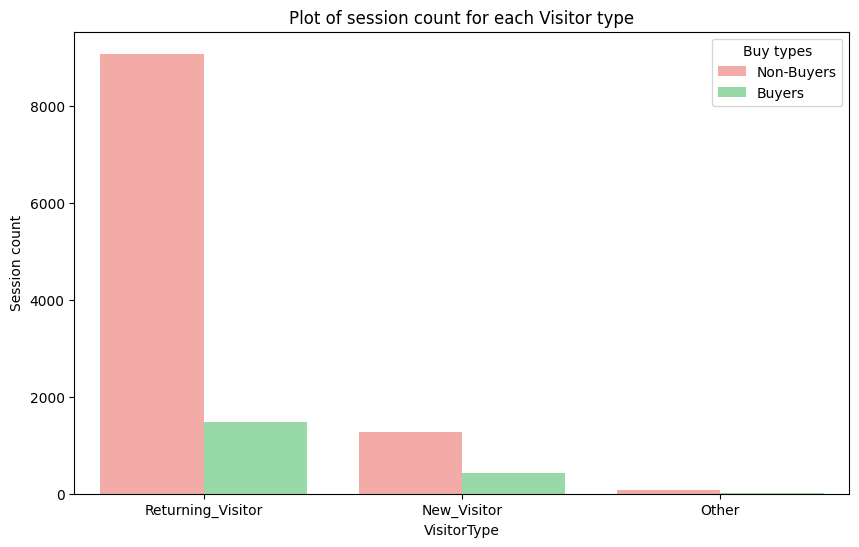

In [15]:
#Group df
visitor_df = df.groupby(['VisitorType', 'Revenue'])['Revenue'].size().reset_index(name='cnt').sort_values('cnt', ascending=False)

#Change name
visitor_df.loc[visitor_df['Revenue']==True, 'Revenue']  = 'Buyers'
visitor_df.loc[visitor_df['Revenue']==False, 'Revenue'] = 'Non-Buyers'

#Plot
plt.figure(figsize=(10, 6))
colors = sns.color_palette('pastel')[2:4][::-1]
sns.barplot(data=visitor_df, 
            x='VisitorType', 
            y='cnt', 
            hue='Revenue',
            palette=colors)
plt.legend(title='Buy types')
plt.ylabel("Session count")
plt.title("Plot of session count for each Visitor type")
plt.show()

The bar plot reveals that **Returning Visitors** account for a higher session count than **New Visitors**. However, the proportion of Buyers among Returning Visitors is significantly lower than Non-Buyers. In contrast, the proportion of Buyers among New Visitors is closer to that of Non-Buyers. This indicates that 
> While Returning Visitors are more numerous, **New Visitors** have a relatively **higher rate of purchase**.

## Engagement metrics analysis <a class="anchor"  id="rate_analysis"></a>

This section analyzes user interaction with webpages by focusing on engagement metrics. The analysis leverages regression plots to describe trends in these metrics.

**Features to be consier**
* BounceRates
* ExitRates
* PageValues

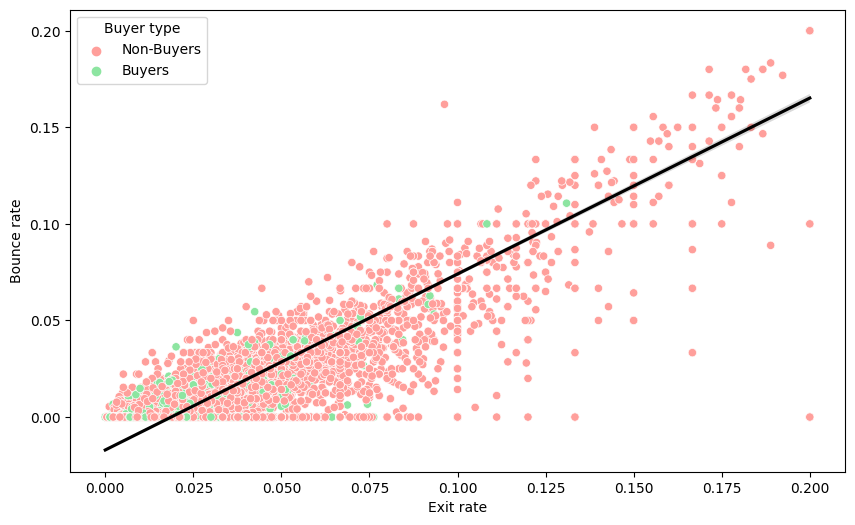

In [16]:
df_bounce_exit = df.copy()
df_bounce_exit['Revenue'] = df_bounce_exit['Revenue'].map({True: 'Buyers', False: 'Non-Buyers'})

# Define custom colors from 'pastel' palette
pastel_palette = sns.color_palette("pastel")
custom_colors = {'Buyers' : pastel_palette[2], 
                 'Non-Buyers': pastel_palette[3]}  # Green for True, Red for False

# Use custom colors in scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_bounce_exit, x='ExitRates', y='BounceRates', hue='Revenue', palette=custom_colors)

# Add regression line
sns.regplot(data=df_bounce_exit, x='ExitRates', y='BounceRates', scatter=False, color='Black')

plt.xlabel('Exit rate')
plt.ylabel('Bounce rate')
plt.legend(title='Buyer type')
plt.show()


The analysis of the relationship between bounce rates and exit rates reveals a **positive correlation**. This suggests that increasing exit rates lead to higher bounce rates

Furthermore, the concentration of Buyers is higher in regions with lower bounce and exit rates. This indicates that
> * Sessions with **higher exit and bounce rates** have a **lower likelihood** of resulting in a product **purchase.** 
> * Lower exit and bounce rates are conducive to purchases.

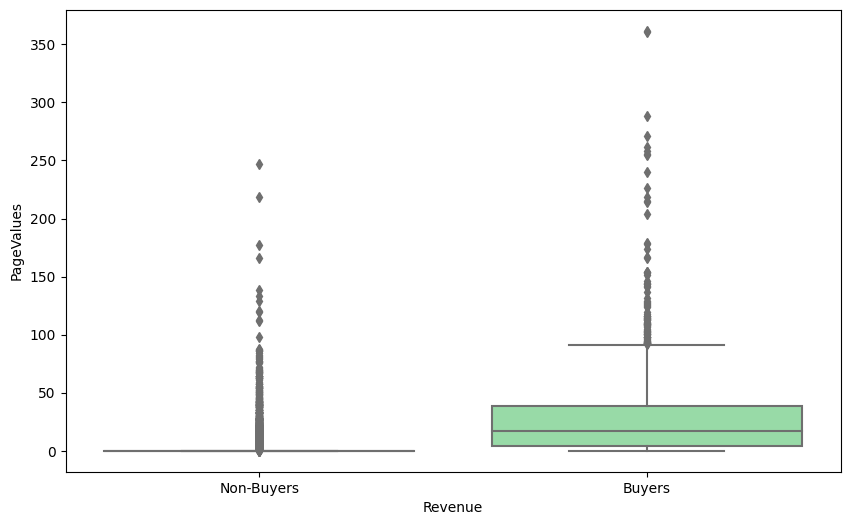

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_bounce_exit, y='PageValues', x='Revenue', palette=custom_colors)
plt.show()

The boxplot demonstrates that **page values** significantly influence customer purchase decisions. However, this plot alone may not fully capture the nuances of the PageValues feature, warranting further in-depth analysis.

The data is segmented to compare sessions where PageValue is zero with those where PageValue is greater than zero.

In [18]:
pg_val_rev_true = df[(df['PageValues'] >0) & (df['Revenue'] == True)]['Revenue'].count()
pg_nonval_rev_true = df[(df['PageValues'] == 0) & (df['Revenue'] == True)]['Revenue'].count()
pg_val_rev_false = df[(df['PageValues'] >0) & (df['Revenue'] == False)]['Revenue'].count()
pg_nonval_rev_false = df[(df['PageValues'] == 0) & (df['Revenue'] == False)]['Revenue'].count()

# Constructing the dictionary
pg_rev_data = {
    'Session count of page value = 0': [pg_nonval_rev_true, pg_nonval_rev_false],
    'Session count of page value > 0': [pg_val_rev_true, pg_val_rev_false]}

# Creating the DataFrame
pg_rev_df = pd.DataFrame(pg_rev_data, index=['Buyers', 'Non-Buyers'])
pg_rev_df

,Session count of page value = 0,Session count of page value > 0
Buyers,370,1538
Non-Buyers,9230,1192


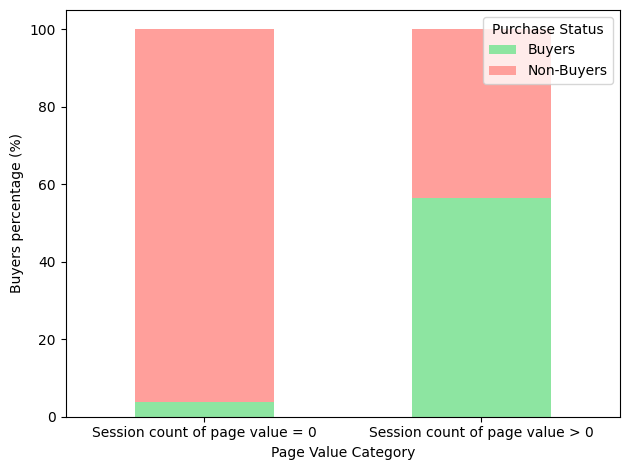

In [19]:
# Calculate the percentages across the columns, then transpose for plotting
pg_rev_df_percent = (pg_rev_df.div(pg_rev_df.sum(axis=0), axis=1) * 100).T

# Plotting
# plt.figure(figsize=(12, 8))
colors = sns.color_palette('pastel')[2:4]
pg_rev_df_percent.plot(kind='bar', stacked=True, color=colors)

# Adjusting the legend to the upper right
plt.legend(title='Purchase Status', loc='upper right')

# Rotating x-axis labels to horizontal
plt.xticks(rotation=0)

# Adding labels and title
plt.xlabel('Page Value Category')
plt.ylabel('Buyers percentage (%)')
# plt.title('Stacked Percentage of Buyers and Non-Buyers by Page Value Category')

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


The analysis of buyer percentages shows a marked increase in purchases when sessions involve non-zero page values. Conversely, sessions with a zero page value correspond to a lower percentage of buyers. This indicates that 
> The **PageValue** metric is a strong influencer of visitor purchasing decisions.

## **Trend Analysis over Time** <a class="anchor"  id="time_series_analysis"></a>

This analysis aims to understand visitor behavior over a specific one-year period. The focus is on comparing the counts of sessions resulting in purchases (Buyers) versus those that don’t (Non-Buyers). To gain deeper insights into visitor behavior, data relating to weekends and special days are also considered.

**Features to be consider**
* Revenue
* Month
* Weekend
* Special day

In [20]:
def annotate_plot(dataframe, column, color, ax):
    for i, point in dataframe.iterrows():
        ax.text(point['Month'], point[column], str(point[column]), color='grey', ha='center', va='bottom')

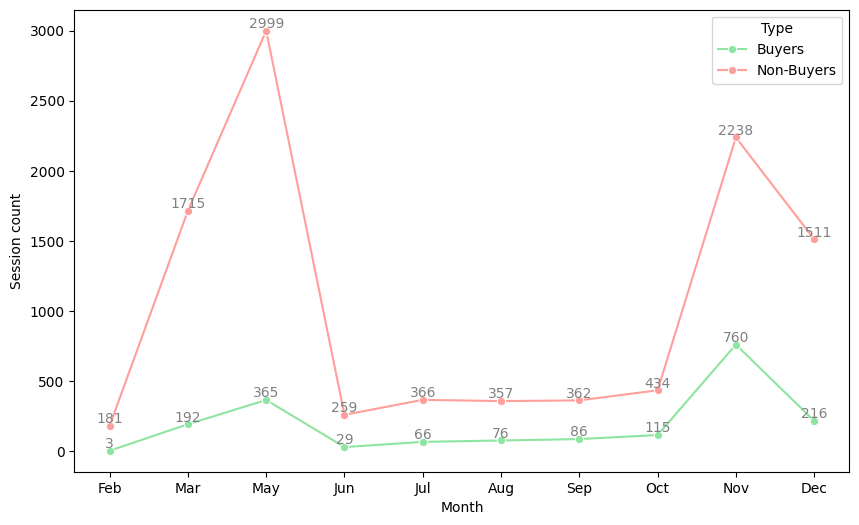

In [21]:
month_customer = df[df['Revenue']==True].groupby('Month')['Revenue'].agg(Buyers='count').reset_index()
month_customer['Non-Buyers']=df[df['Revenue']==False].groupby('Month')['Revenue'].agg('count').values


plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get current axis

# Plot and annotate for Buyers
buyers_color = sns.color_palette('pastel')[2]
sns.lineplot(data=month_customer, x='Month', y='Buyers', label='Buyers', color=buyers_color, marker='o', ax=ax)
annotate_plot(month_customer, 'Buyers', buyers_color, ax)

# Plot and annotate for Non-Buyers
non_buyers_color = sns.color_palette('pastel')[3]
sns.lineplot(data=month_customer, x='Month', y='Non-Buyers', label='Non-Buyers', color=non_buyers_color, marker='o', ax=ax)
annotate_plot(month_customer, 'Non-Buyers', non_buyers_color, ax)

plt.ylabel('Session count')
plt.legend(title="Type")
plt.show()

The time-series plot clearly shows that between **June and October**, the session count for Non-Buyers remains relatively constant at around 360 sessions per month. For Buyers, there is an increase in sessions from June to October. 

The highest session counts are observed in May and November, indicating peak activity for both Buyers and Non-Buyers. 

> This indicates that **May and November** are significant months for product purchases.

Given the observed trends, the influence of special days on the volume of Buyers and Non-Buyers is considered for a more comprehensive understanding.

In [22]:
# Function to apply a style to rows
def highlight_greater_than_zero(s):
    return ['background-color: yellow' if v > 0 else '' for v in s]

special_day_df = df[['Month','SpecialDay']].groupby(['Month']).agg('mean').reset_index()

# Apply the style to the DataFrame
styled_df = special_day_df.style.apply(highlight_greater_than_zero, subset=['SpecialDay'])
styled_df

,Month,SpecialDay
0,Feb,0.233696
1,Mar,0.000000
2,May,0.212366
3,Jun,0.000000
4,Jul,0.000000
5,Aug,0.000000
6,Sep,0.000000
7,Oct,0.000000
8,Nov,0.000000
9,Dec,0.000000


The time-series analysis highlights May and November as months with notably higher session counts. While the dataset records special days only in February and May, the observed spikes in May could be attributed to **Mother's Day**. 

Conversely, even though November and December lack recorded special days, the increase in sessions suggests that **visitors are likely purchasing gifts for Christmas or the New Year.**

To further understand visitor behavior, the analysis extends to considering the distribution of purchase sessions between weekdays and weekends.

In [23]:
weekend_df = df.groupby(['Weekend', 'Revenue']).size().reset_index(name='cnt')
weekend_df = weekend_df.pivot(index='Weekend', columns='Revenue', values='cnt')
# Rename the columns
weekend_df = weekend_df.rename(columns={True: 'Buyers', False: 'Non-Buyers'})
weekend_df.columns = [''.join(col).strip() for col in weekend_df.columns.values] #flattern column level

# Rename the index
weekend_df = weekend_df.rename(index={True: 'Week_end', False: 'Week_day'})

weekend_df['BuyersPct'] = weekend_df['Buyers'] / (weekend_df['Buyers'] + weekend_df['Non-Buyers']) * 100
weekend_df

,Non-Buyers,Buyers,BuyersPct
Weekend,,,
Week_day,8053,1409,14.891144
Week_end,2369,499,17.398884


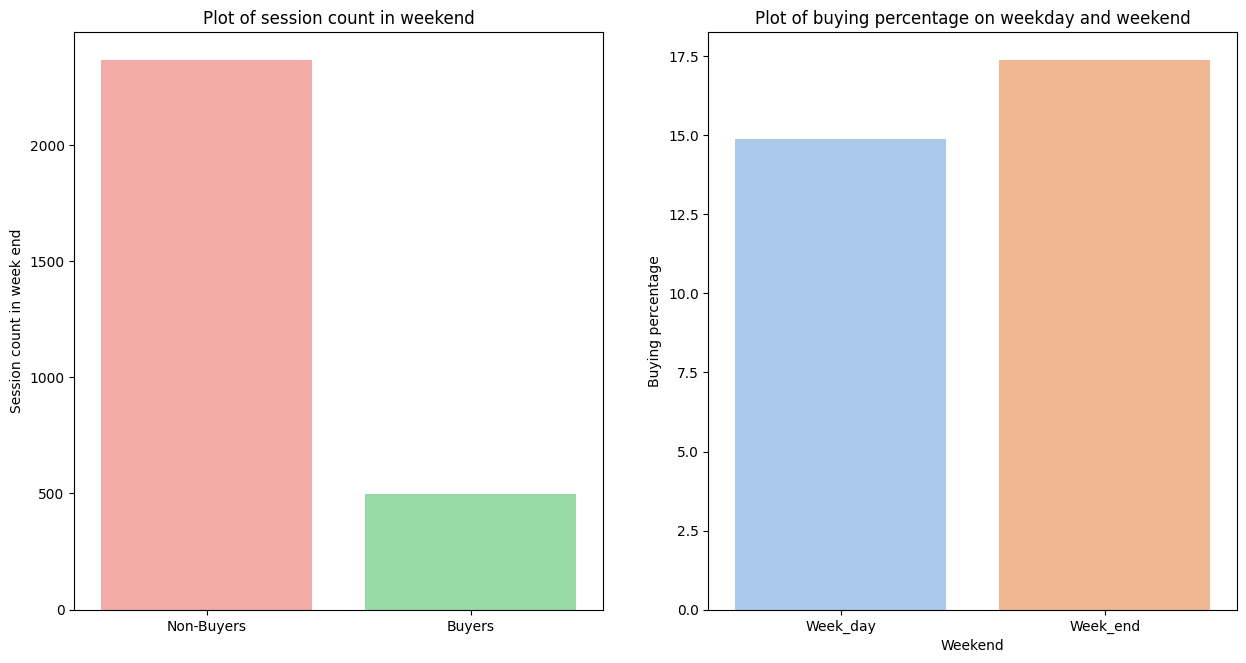

In [24]:
colors = sns.color_palette('pastel')[2:4][::-1]
plt.figure(figsize=(15, 7.5))
plt.subplot(1, 2, 1)
ax1=sns.barplot(x=weekend_df.loc['Week_end', ['Non-Buyers', 'Buyers']].index, 
            y=weekend_df.loc['Week_end', ['Non-Buyers', 'Buyers']].values, 
            palette=colors)
plt.ylabel("Session count in week end")
ax1.set_title("Plot of session count in weekend")


plt.subplot(1, 2, 2)
ax2=sns.barplot(x=weekend_df.index, 
            y=weekend_df['BuyersPct'],
            palette='pastel')
plt.ylabel("Buying percentage")
ax2.set_title("Plot of buying percentage on weekday and weekend")

plt.show()


Analysis reveals that while the absolute count of Buyer **sessions is lower on weekends**, the proportion of sessions resulting in purchases is higher during weekends compared to weekdays. 
> This indicates that while most product searching and buying **activities occur on weekdays**, the likelihood of completing a purchase is **higher during weekends**.

## Analysis with the category variables <a class="anchor"  id="category_analysis"></a>

This final section of the exploratory analysis focuses on categorical features, including Operating System (OS), Browser, Region, and Traffic Type. Sessions are grouped by these categories and visualized using pie charts to aid in understanding visitor behavior across different categories.

Define the function for easier to handle the plot.

In [25]:
def cut_small_portion(data, labels, threshold):
    """
    Groups small portions of data into an 'Others' category.

    :param data: Array-like, the data values for the pie chart.
    :param labels: Array-like, the labels corresponding to the data.
    :param threshold: Float, the threshold to determine small portions (as a fraction).
                      Portions contributing less than this fraction of the total are grouped.
    :return: Tuple of two elements (cut_data, cut_labels) for plotting.
    """
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame({'Label': labels, 'Data': data})

    # Sort by data value
    df.sort_values('Data', ascending=False, inplace=True)

    # Calculate the cumulative sum and total
    df['Cumulative'] = df['Data'].cumsum()
    total = df['Data'].sum()

    # Determine the cut-off point
    cutoff = total * threshold

    # Group small portions into 'Others'
    small_groups = df[df['Cumulative'] > cutoff]
    others_sum = small_groups['Data'].sum()

    # Create new DataFrame without small groups and add 'Others'
    cut_df = df[df['Cumulative'] <= cutoff]
    if others_sum > 0:
        others_df = pd.DataFrame({'Label': ['Others'], 'Data': [others_sum]})
        cut_df = pd.concat([cut_df, others_df], ignore_index=True)

    # Prepare data and labels for return
    cut_data = cut_df['Data'].values
    cut_labels = cut_df['Label'].values

    return cut_data, cut_labels

def pie_plot(ax, data, labels, colors, lg_title, title):
    ax.pie(data, labels=labels,
             autopct = '%1.1f%%',
             shadow = True,
             startangle=90, colors=colors,
             textprops={'fontsize': 15})
    ax.legend(title=lg_title)
    ax.set_title(title, fontsize=15)

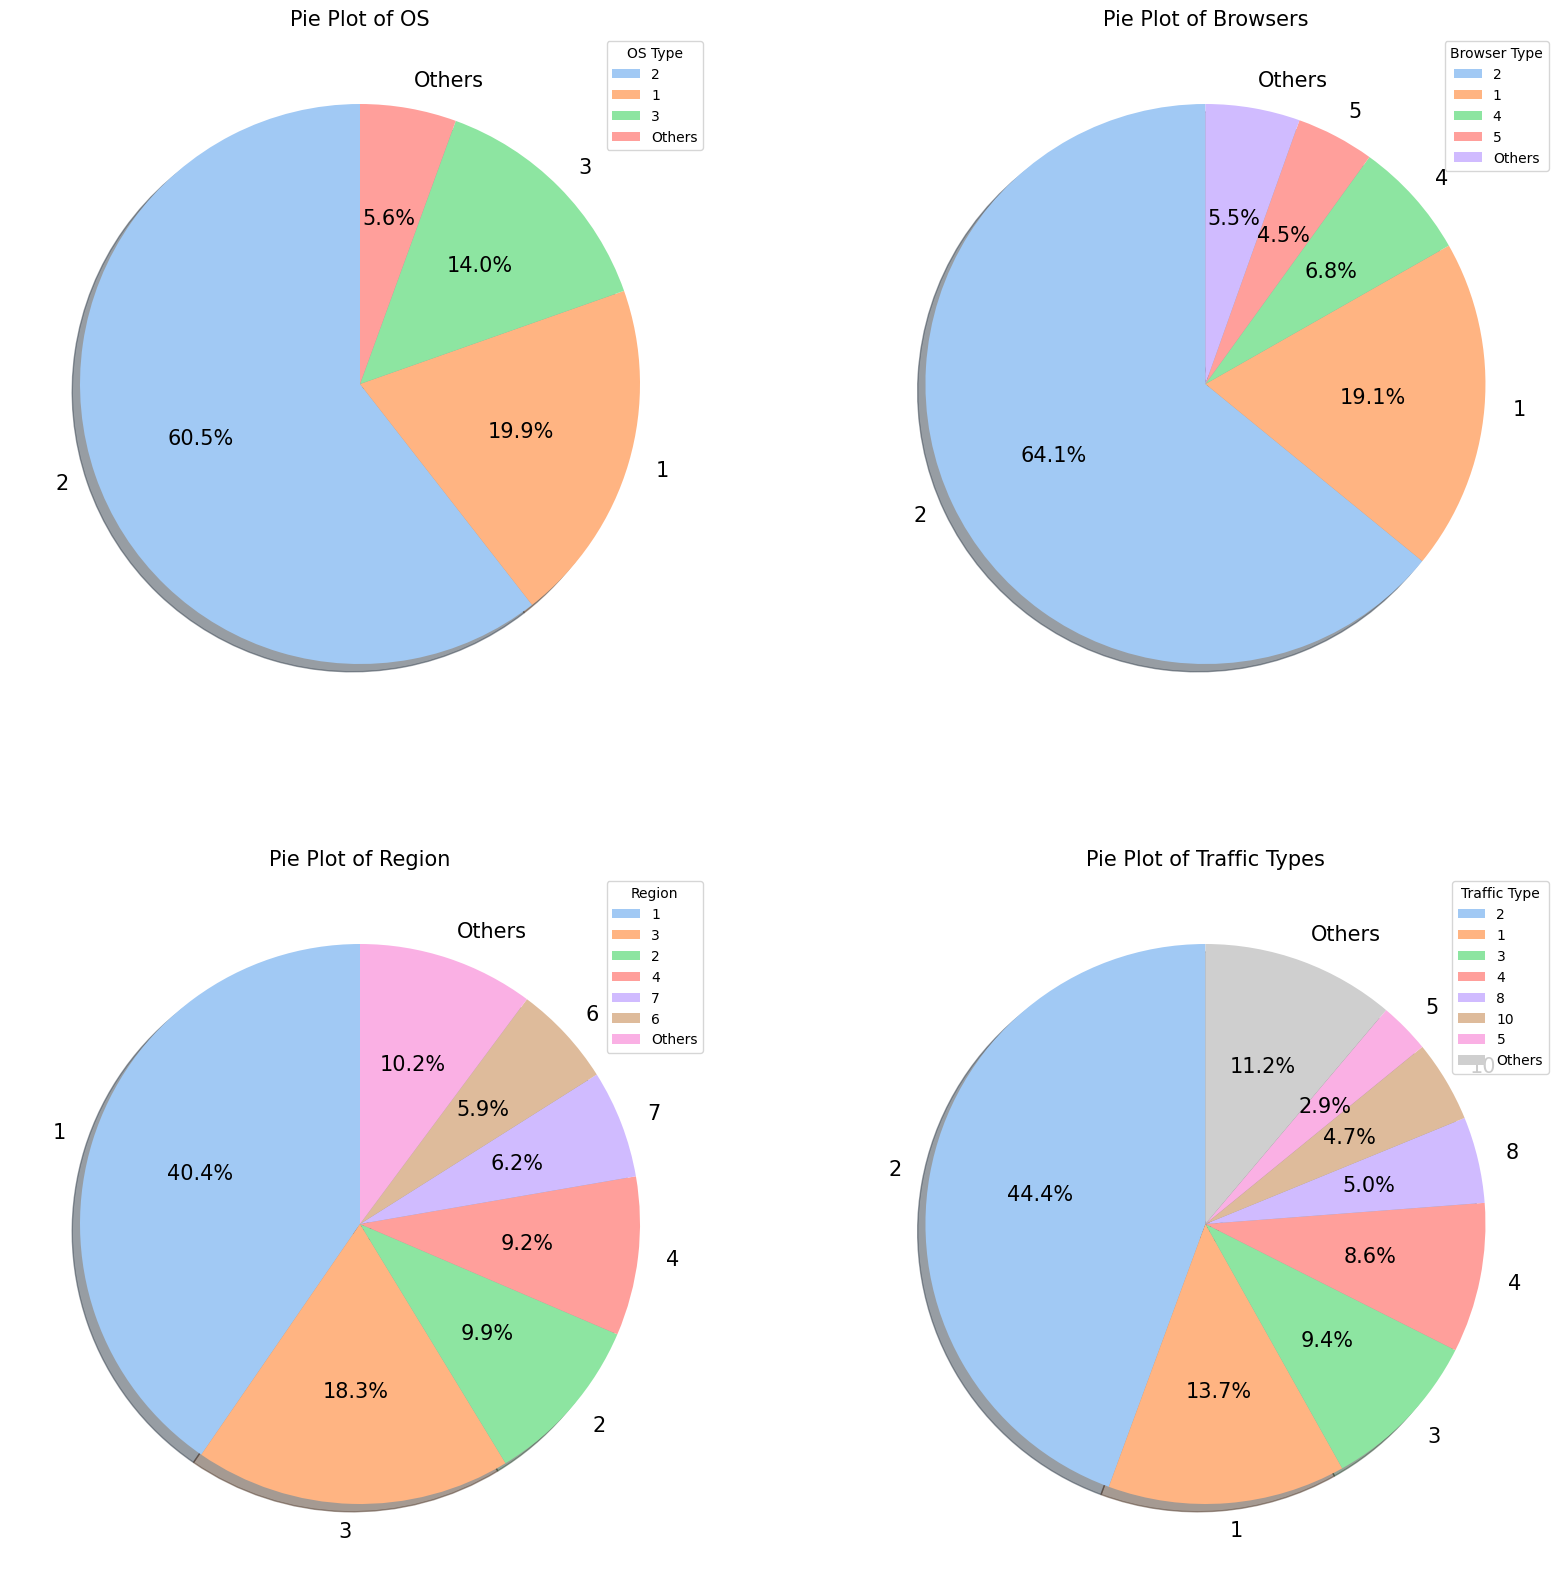

In [26]:
OS=df.groupby('OperatingSystems')['Revenue'].agg('sum').reset_index().sort_values('Revenue')
os_colors = sns.color_palette('pastel')[0:len(OS)-1]
os_pie_data, os_pie_labels = cut_small_portion(OS['Revenue'], OS['OperatingSystems'], 0.95)

browser= df.groupby('Browser')['Revenue'].agg('sum').reset_index().sort_values('Revenue')
browser_colors = sns.color_palette('pastel')[0:len(browser)-1]
browser_pie_data, browser_pie_labels = cut_small_portion(browser['Revenue'], browser['Browser'], 0.95)

region = df.groupby('Region')['Revenue'].agg('sum').reset_index().sort_values('Revenue')
region_colors = sns.color_palette('pastel')[0:len(region)-1]
region_pie_data, region_pie_labels = cut_small_portion(region['Revenue'], region['Region'], 0.90)

traffic_type = df.groupby('TrafficType')['Revenue'].agg('sum').reset_index().sort_values('Revenue')
traffic_type_colors = sns.color_palette('pastel')[0:len(traffic_type)-1]
traffic_type_pie_data, traffic_type_pie_labels = cut_small_portion(traffic_type['Revenue'], traffic_type['TrafficType'], 0.91)

# Plotting
plt.figure(figsize=(20, 20))

# Operating Systems subplot
os_ax = plt.subplot(2, 2, 1)
pie_plot(os_ax, os_pie_data, os_pie_labels, os_colors, 'OS Type', 'Pie Plot of OS')

# Browsers subplot
browser_ax = plt.subplot(2, 2, 2)
pie_plot(browser_ax, browser_pie_data, browser_pie_labels, browser_colors, 'Browser Type', 'Pie Plot of Browsers')

# Region subplot
region_ax = plt.subplot(2, 2, 3)
pie_plot(region_ax, region_pie_data, region_pie_labels, region_colors, 'Region', 'Pie Plot of Region')

# Traffic Type subplot
traffic_type_ax = plt.subplot(2, 2, 4)
pie_plot(traffic_type_ax, traffic_type_pie_data, traffic_type_pie_labels, traffic_type_colors, 'Traffic Type', 'Pie Plot of Traffic Types')

plt.show()

The pie charts display the distribution of sessions across various OS, Browser, Region, and Traffic types.

* A significant majority (over 60%) of sessions use **OS type 2** and **Browser type 2**. 
* **Region 1** accounts for the majority of visitor sessions. 
* **Traffic Type 2** dominates session sources. 

To gain a deeper understanding of visitor behavior, the buy rates for each major category are analyzed. This will provide insights into customer behavior, differentiating between buyers and non-buyers in each category. The focus will be on the most prominent categories within OS, Browser, Region, and Traffic types.

1. Indicates buy rates of OS group 2, 1, 3
2. Indicates buy rates of Browser type 2, 1
3. Indicates buy rates of Region 1, 3, 2, 4
4. Indicates buy rates of Traffic types 2, 1, 3, 4

In [27]:
def get_buy_rates(df, column, id_array):
    buyrates = df[df[column].isin(id_array)].groupby([column, 'Revenue']).size().reset_index(name='cnt')
    buyrates = buyrates.pivot(index=column, columns='Revenue', values='cnt')
    buyrates['BuyRates'] = buyrates[True] / (buyrates[True] + buyrates[False]) * 100 
    buyrates['TotalCount'] = buyrates[True] + buyrates[False]
    buyrates = buyrates.reset_index().sort_values('TotalCount', ascending=False) #sort data by total counts, so it will match with the pie chart
    return buyrates

def bar_plot_buyrates(ax, df, column, title):
    sns.barplot(data=df, x=column, y='BuyRates', palette='pastel', order=df[column])
    ax.set_title(title)
    ax.set_ylim(0,25)
    plt.ylabel('Buy rate (%)')

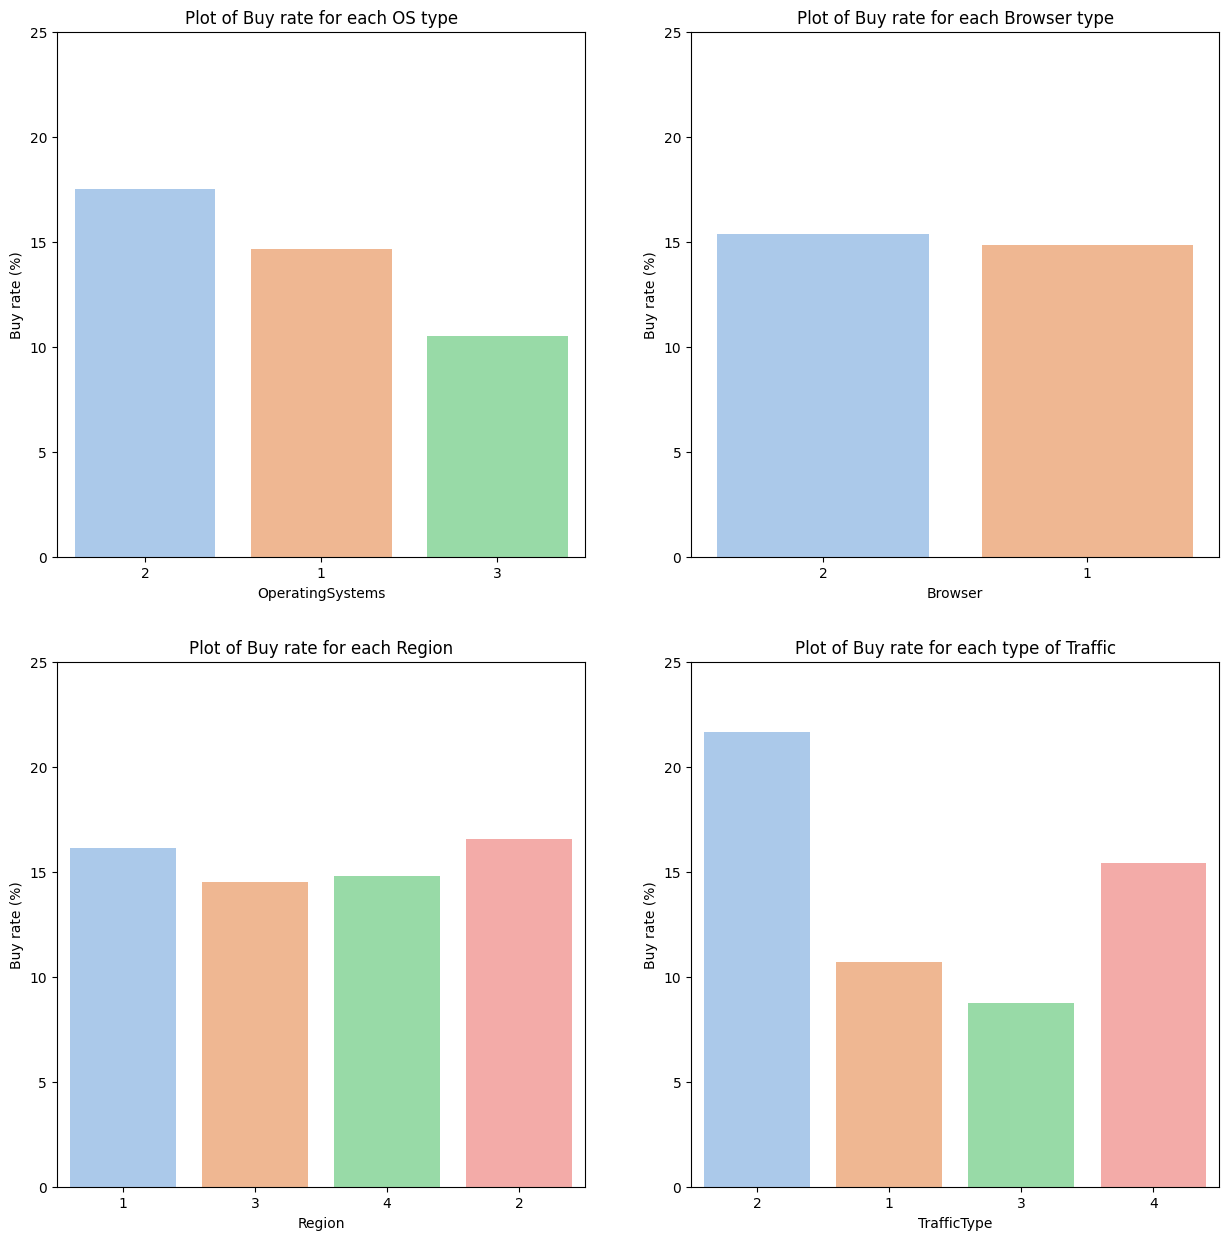

In [28]:
# Create new buyrates df
os_buyrates = get_buy_rates(df, 'OperatingSystems', [2,1,3])
browser_buyrates = get_buy_rates(df, 'Browser', [2,1])
region_buyrates = get_buy_rates(df, 'Region', [1,3,2,4])
traffic_buyrates = get_buy_rates(df, 'TrafficType', [2,1,3,4])

plt.figure(figsize=(15, 15))

ax1 = plt.subplot(2, 2, 1)
bar_plot_buyrates(ax1, os_buyrates, 'OperatingSystems', 'Plot of Buy rate for each OS type')

ax2 = plt.subplot(2, 2, 2)
bar_plot_buyrates(ax2, browser_buyrates, 'Browser', 'Plot of Buy rate for each Browser type')

ax3 = plt.subplot(2, 2, 3)
bar_plot_buyrates(ax3, region_buyrates, 'Region', 'Plot of Buy rate for each Region')

ax4 = plt.subplot(2, 2, 4)
bar_plot_buyrates(ax4, traffic_buyrates, 'TrafficType', 'Plot of Buy rate for each type of Traffic')

plt.show()

The comparison between session counts and buy rates for each Operating System, Browser, Region, and Traffic Type reveals several insights:

* The buy rates for **OS types 2, 1, and 3** align with their session counts, indicating a correlation between the frequency of sessions and the likelihood of purchase.
* There is no significant difference in the buy rates between **Browser types 2 and 1.**
* Buy rates across different **Regions** do not show significant variation.
* **Traffic Type 2** has a notably higher buy rate compared to other types, **suggesting its effectiveness in converting sessions into purchases.**

## EDA Conclusion <a class="anchor"  id="conclusion"></a>

## Key Business Insights <a class="anchor"  id="insight"></a>

### Page Interaction Analysis
**Product-Related Pages**: There is a significant correlation between engagement (both in terms of views and duration) on Product-Related pages and the likelihood of a purchase. The data suggests that visitors who spend more time on these pages are more likely to buy.
### Engagement Metrics Analysis
**Bounce and Exit Rates**: Sessions with lower bounce and exit rates are more likely to result in purchases. High exit and bounce rates are indicators of lower user engagement and a reduced likelihood of sales.

**Influence of PageValues**: Higher PageValues are strongly associated with a greater likelihood of transactions, emphasizing the importance of this metric in assessing user purchase intent.
### Visitor Type Analysis
**New Visitor type**: Returning Visitors are more frequent but have a lower chance to buy compared to New Visitors. This suggests the importance of strategies targeting both visitor retention and conversion.
### Trend Analysis over Time
**Seasonal Trends**: There is a noticeable increase in purchases during May and November. The data suggests these months are critical periods for marketing and sales initiatives.
### Categorical Analysis
**OS Preference**: OS type 2 is the most commonly used among visitors, suggesting the need for optimal compatibility and performance on this OS.

**Browser Preference**: Browser type 2 is predominant, indicating its importance for website optimization.

**Regional Traffic**: The majority of traffic originates from Region 1, highlighting the potential for targeted marketing and product strategies in this region.

**Effective Traffic Sources**: Traffic Type 2 stands out as the most significant source of sessions leading to purchases.

## Recommendations <a class="anchor"  id="recommend"></a>
**Enhance Product-Related Pages**: Develop and optimize these pages to foster user engagement and increase sales likelihood.

**Reduce Bounce and Exit Rates**: Implement strategies to engage users effectively, thereby reducing bounce and exit rates.

**Utilize PageValue Insights**: Leverage high PageValues as indicators of user interest and purchase intent to guide content strategy and marketing efforts.

**Capitalize on Peak Seasons**: Develop targeted marketing campaigns and inventory strategies for May and November.

**Optimize for Key OS and Browser**: Focus on ensuring a seamless user experience on **OS type 2 and Browser type 2**.

**Focus on Regions**: Develop region-specific marketing strategies, particularly for **Region 1**, to cater to local preferences and trends.

**Prioritize Effective Traffic Sources**: Allocate resources and strategies towards maximizing the potential of **Traffic Type 2**.

# Predictive modeling <a class="anchor"  id="predict"></a>
This section covers the predictive modeling process, including model initialization, score interpretation, preprocessing, cross-validation, and hyperparameter tuning. The goal is to identify key features and predict the **likelihood of being a Buyer**, as indicated by the 'True' label in the Revenue feature. Given the dataset's class imbalance, SMOTE (Synthetic Minority Over-sampling Technique) is employed for preprocessing. A **Random Forest classifier** is utilized for the predictive model.

**Basic import**

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, make_scorer
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import dump, load

**Define some useful function**

In [30]:
def highlight_metrics(rows, colors_for_metrics):
    style = []
    for color in colors_for_metrics:
        style.append('background-color: {}'.format(color))
    return style

The dataset is split into training and testing sets, with the `stratify=y` parameter ensuring a consistent class ratio (True/False) between these sets. The 'Month' feature, among others, has been excluded from the analysis.

In [31]:
# X = df.drop(columns=['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Revenue'])
X = df.drop(columns=['Month', 'Revenue'])
y = df['Revenue']
SEED = 1997

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    stratify=y, 
                                                    random_state=SEED)

# Encode the data after splitting to prevent data leakage
X_train = pd.get_dummies(X_train, columns=['OperatingSystems', 'Browser', 'Region', 'TrafficType','VisitorType'])
X_test = pd.get_dummies(X_test, columns=['OperatingSystems', 'Browser', 'Region', 'TrafficType','VisitorType'])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

RF = RandomForestClassifier(random_state=SEED)

RF.fit(X_train, y_train)

RandomForestClassifier(random_state=1997)

## Key features <a class="anchor"  id="keyfeature"></a>
After fit the Random forest model, let's find the key importance features by `feature_importances_` . this help to understand visitor's be havior that what is key factor for deciding purchase

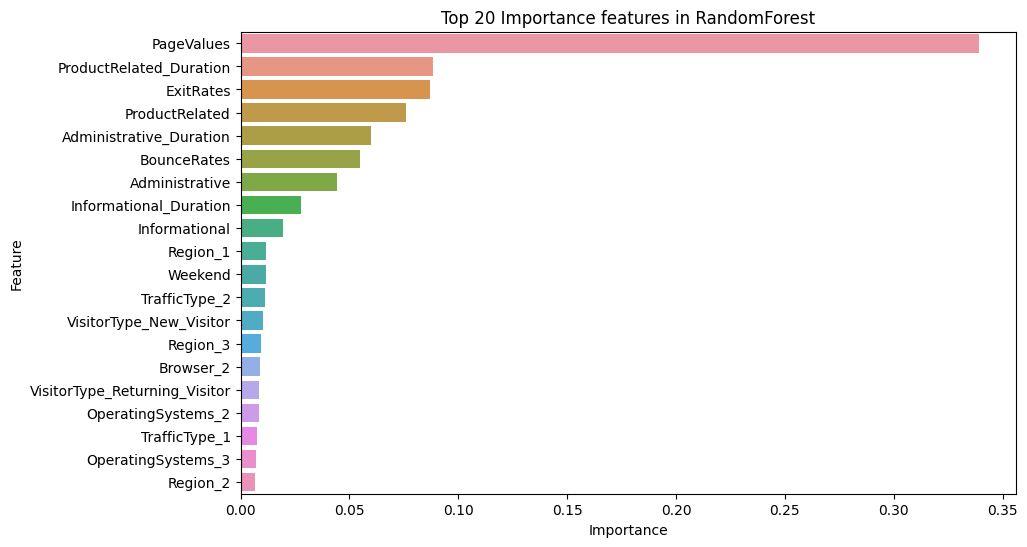

In [32]:
importances = RF.feature_importances_
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.iloc[0:20,:])

plt.title('Top 20 Importance features in RandomForest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The bar plot illustrates the importance of each feature, with '**PageValue**' emerging as the most influential, followed by interactions on **Product-Related** pages and **engagement metrics**. This aligns with the insights from the EDA, reinforcing the significance of these factors in influencing purchase decisions.

Predict the label, then interprete the first outcome.

In [33]:
y_pred = RF.predict(X_test)

score = RF.score(X_test, y_test)
confusion_mtrx = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report)

colors_for_metrics = [['yellow', 'yellow', 'yellow', 'None']]
style_df = report_df.style.apply(highlight_metrics, args=colors_for_metrics, subset=['True'])
style_df.format('{:.2f}')
style_df

,False,True,accuracy,macro avg,weighted avg
precision,0.91,0.73,0.89,0.82,0.89
recall,0.97,0.51,0.89,0.74,0.89
f1-score,0.94,0.60,0.89,0.77,0.89
support,3127.00,572.00,0.89,3699.00,3699.00


Upon examining the classification report, it's evident that the class imbalance significantly impacts the model's results, with a larger number of 'False' (3127) cases compared to 'True' (572). This imbalance means the model is more effective at identifying **Non-Buyers**, which is useful if the business goal is to develop new campaigns targeting this group. However, the model shows lower precision, recall, and f1-score for the True class, indicating 
> it is less effective at correctly identifying potential **Buyers**, which is a crucial aspect if the objective is to target this demographic.

The implementation aims to accurately identify the group of actual Buyers among visitors. Thus, the focus is on maximizing both recall and precision for the positive (True) class. **Recall** and **precision** often present a trade-off in model adjustment; improving one can sometimes lead to a reduction in the other. In light of this, the **f1-score**, which balances precision and recall, is particularly suitable as the primary evaluation metric for this imbalanced dataset. It effectively reflects the model's performance in terms of both precision and recall, providing a more holistic view of its ability to identify potential Buyers.

## **Application of SMOTE** <a class="anchor"  id="smote"></a>

SMOTE, or Synthetic Minority Over-sampling Technique, is used for addressing class imbalance by up-sampling the minority class based on the data from their neighbors. The goal is to balance the True/False class distribution. It's important to note that SMOTE should only be applied to the training dataset, leaving the test set untouched until evaluation.


In [34]:
#Initiate SMOTE instances
sm = SMOTE(random_state=SEED)

#Initiate Random forest
RF = RandomForestClassifier(random_state=SEED)
X_res, y_res = sm.fit_resample(X_train, y_train)
RF.fit(X_res, y_res)

y_pred = RF.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
pd.set_option('display.precision', 2)
report_df = pd.DataFrame(report)

colors_for_metrics = [['red', 'green', 'green', 'None']]
style_df = report_df.style.apply(highlight_metrics, args=colors_for_metrics, subset=['True'])
style_df.format('{:.2f}')
style_df

,False,True,accuracy,macro avg,weighted avg
precision,0.94,0.62,0.89,0.78,0.89
recall,0.92,0.68,0.89,0.80,0.89
f1-score,0.93,0.65,0.89,0.79,0.89
support,3127.00,572.00,0.89,3699.00,3699.00


After applying SMOTE preprocessing, the overall model accuracy slightly decreases from 0.90 to 0.88. The **precision for the True class significantly drops** from 0.73 to 0.62, while the **recall for the True class increases** from 0.51 to 0.68. This is a typical trade-off observed when attempting to reduce false negatives. 
> The model becomes more effective in correctly identifying True cases (**Buyers**), evidenced by the increased recall. 

Despite a reduction in precision, the **improved f1-score** indicates enhanced overall quality of the model in classifying cases correctly.

## **Cross Validation** <a class="anchor"  id="crossvalidation"></a>
After evaluating the performance of the RandomForestClassifier with SMOTE on the training set, cross-validation is employed to assess the model's robustness.

In [35]:
# Define the file path for saved results
scores_file = '/kaggle/working/cross_validate_scores_rev2.joblib'

# Check if the saved results exist
if os.path.exists(scores_file):
    # Load the results
    scores = load(scores_file)
    print("Loaded cross-validation scores from file.")
else:
    # Define your pipeline and cross-validation
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(random_state=SEED))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'], return_train_score=True, verbose=1)
    
    # Save the results
    dump(scores, scores_file)
    print("Cross-validation completed and results saved.")

Cross-validation completed and results saved.


In [36]:
scores_df = pd.DataFrame(scores)[['test_accuracy', 'test_precision', 'test_recall', 'test_f1']].T
scores_df['avg'] = scores_df.mean(axis=1)
colors_for_metrics = [['None','red', 'green','green']]
style_df = scores_df.style.apply(highlight_metrics, args=colors_for_metrics, subset=['avg'])
style_df.format('{:.2f}')
style_df

,0,1,2,3,4,avg
test_accuracy,0.89,0.90,0.89,0.89,0.89,0.89
test_precision,0.62,0.67,0.64,0.64,0.64,0.64
test_recall,0.69,0.68,0.69,0.69,0.64,0.68
test_f1,0.65,0.67,0.67,0.66,0.64,0.66


The cross-validation results reaffirm that the recall across all folds is consistently higher than the precision. The average recall over all cross-validation folds is 0.68, a substantial improvement over the original model's recall of 0.51. This confirms that the model, after applying SMOTE, is more adept at identifying the **Buyer** class (True cases) compared to the original model. 
> It indicates the model's enhanced capability in correctly classifying potential Buyers.

Additionally, there is an observable rise in the **f1-score**, averaging 0.65, compared to the initial model. This improvement in f1-score is particularly meaningful because it indicates a better balance between precision and recall

## **Hyper parameter tunning** <a class="anchor"  id="hyper"></a>

After confirming that the preprocessing method with SMOTE aligns with the expected results, the next step is to fine-tune the hyperparameters of the RandomForestClassifier. This process aims to enhance the model's capability to accurately **identify Buyers**.

In [37]:
model_file = '/kaggle/working/grid_rf.joblib_rev2'

# Check if the saved model exists
if os.path.exists(model_file):
    # Load the model
    grid_rf = load(model_file)
    print("Loaded saved model from:", model_file)
    
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    rf_params = {
        'smote__k_neighbors': [3, 5, 7], #default is 5
        'rf__n_estimators': [100, 200],  #default is 100
        'rf__criterion':['gini', 'entropy'], #default is gini
        'rf__min_samples_leaf':[1, 5, 10], #default 1
        'rf__max_features': ['sqrt', 'log2'] #default is sqrt
    }

    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1_score': make_scorer(f1_score),
    }

    # Initiate intances
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(random_state=SEED))
    ])

    grid_rf = GridSearchCV(estimator=pipeline, param_grid=rf_params, cv=cv, scoring=scoring, refit='f1_score', return_train_score=True)
    grid_rf.fit(X_train, y_train)
    
    # Save model 
    dump(grid_rf, model_file)
    print('The model has been saved in: ', model_file)
    

# Best parameters and best score
print("Best parameters:", grid_rf.best_params_)
print("Best score:", grid_rf.best_score_)

The model has been saved in:  /kaggle/working/grid_rf.joblib_rev2
Best parameters: {'rf__criterion': 'gini', 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100, 'smote__k_neighbors': 5}
Best score: 0.6724077947311276


In [38]:
cv_df = pd.DataFrame(grid_rf.cv_results_)
cv_df = cv_df[cv_df['params'] == grid_rf.best_params_][['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1_score']].T
colors_for_metrics = [['None','red', 'green','green']]
style_df = cv_df.style.apply(highlight_metrics, args=colors_for_metrics)
style_df.format('{:.2f}')
style_df

,7
mean_test_accuracy,0.89
mean_test_precision,0.61
mean_test_recall,0.75
mean_test_f1_score,0.67


The cross-validation results from the GridSearchCV, optimized for the f1-score, indicate an average test accuracy of 0.89, precision of 0.61, recall of 0.75, and an f1-score of 0.67. These scores, particularly the recall and f1-score, signify an improvement in the model's ability to correctly classify the True class (**Buyers**), balancing both precision and recall effectively.

Use best model for being a representative among 360 models created by GridSearchCV. Then, validate the model with test set. the accuracy, precision, recall and f1 score should be calculated to check whether this best model is overfit or not. 

In [39]:
best_model = grid_rf.best_estimator_
y_pred       = best_model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report)

colors_for_metrics = [['red', 'green', 'green', 'None']]
style_df = report_df.style.apply(highlight_metrics, args=colors_for_metrics, subset=['True'])
style_df.format('{:.2f}')
style_df

,False,True,accuracy,macro avg,weighted avg
precision,0.95,0.59,0.88,0.77,0.90
recall,0.91,0.74,0.88,0.82,0.88
f1-score,0.93,0.66,0.88,0.79,0.89
support,3127.00,572.00,0.88,3699.00,3699.00


The model demonstrates consistent performance on the test set, with an accuracy of 88%. This indicates its effectiveness in classifying both Buyers and Non-Buyers. 
* The precision of 59% suggests that when the model predicts a session as a Buyer, it is correct about 59% of the time. 
* A recall of 74% indicates the model successfully identifies 74.1% of actual Buyers. 
* The f1-score of 0.66, a balanced metric, is notably higher than the initial model's score of 0.60. 
> This improvement confirms the model's enhanced ability to distinguish between Buyers and Non-Buyers, validating the effectiveness of the hyperparameter tuning and SMOTE preprocessing.

## **Conclusion of Predictive Modeling** <a class="anchor"  id="modelconslusion"></a>

In this predictive modeling section, a `RandomForestClassifier` was employed to predict potential Buyers in the Online Retail Dataset. The initial model, although proficient in identifying Non-Buyers, showed limitations in accurately classifying the True class (Buyers), primarily due to class imbalance. To address this, `SMOTE` (Synthetic Minority Over-sampling Technique) was applied, which significantly improved the model's ability to identify Buyers, as evidenced by increased recall and f1-score.

Hyperparameter tuning via `GridSearchCV` further refined the model, striking a better balance between precision and recall. This tuning process, optimized for the f1-score, led to a model that demonstrated an accuracy of 88% on the test set, with notable improvements in recall and f1-score, indicating enhanced capability in distinguishing potential **Buyers** from **Non-Buyers**. 